# VoiceOfBank — 04 Sentiment Analysis (VADER)
**Notebook 4 of 7** — Run locally

Rule-based sentiment analysis using VADER.

**What VADER is:** VADER (Valence Aware Dictionary and sEntiment Reasoner) is a
lexicon and rule-based sentiment tool specifically designed for social media text.
It handles negations, intensifiers, punctuation emphasis, and slang without any training.

**Why use it here:**
- No GPU needed — runs on CPU in seconds
- Strong baseline before BERT (notebook 05)
- Produces compound scores we can compare against star ratings
- Aspect-level scoring without a labelled dataset

**Input:** `data/processed/reviews_clean.csv`

**Output:** `data/processed/reviews_vader.csv`


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from pathlib import Path

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS     = sns.color_palette('muted')
BANKS      = ['Monzo','Starling','Barclays','HSBC','NatWest','Lloyds']
CHALLENGER = ['Monzo','Starling']
PALETTE    = dict(zip(BANKS, sns.color_palette('tab10', 6)))

PROCESSED_DIR = Path('../data/processed')



## 2. Load Data

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'reviews_clean.csv', parse_dates=['date'])

print('Shape:', df.shape)
print('Columns:', list(df.columns))
print()
df.head(3)


Shape: (27142, 17)
Columns: ['reviewId', 'text', 'rating', 'date', 'replyContent', 'bank', 'type', 'has_reply', 'review_len', 'year_month', 'is_complaint', 'text_clean', 'clean_len', 'sentiment', 'bank_id', 'sentiment_id', 'split']



,reviewId,text,rating,date,replyContent,bank,type,has_reply,review_len,year_month,is_complaint,text_clean,clean_len,sentiment,bank_id,sentiment_id,split
0,de2e33fa-8b9f-4d25-b850-ccde652be126,amazing app,5,2026-06-02 09:45:48,NaN,Monzo,Challenger,0,11,2026-06,0,amazing,7,Positive,3,2,train
1,8b63c112-adc9-4102-a10d-c5177e111cb2,love monzo it's so easy to use few people said...,5,2026-06-02 08:25:55,NaN,Monzo,Challenger,0,79,2026-06,0,love easy people said dodgy site cool,37,Positive,3,2,train
2,d658f4cd-ed2d-40a4-92be-5f86d3ab9555,easy to use the app doesn't seem to crash like...,4,2026-06-01 20:49:59,NaN,Monzo,Challenger,0,71,2026-06,0,easy seem crash apps,20,Positive,3,2,test


## 3. VADER Scoring

VADER returns four scores per text:
- `pos` — proportion of positive sentiment
- `neu` — proportion of neutral sentiment
- `neg` — proportion of negative sentiment
- `compound` — normalised overall score from -1 (most negative) to +1 (most positive)

We use the **raw text** (not cleaned) for VADER because it relies on
punctuation, capitalisation, and emoticons as sentiment signals.
Cleaning would remove these signals.


In [3]:
sia = SentimentIntensityAnalyzer()

# Score on raw text — VADER needs punctuation and capitalisation
print('Scoring 30,000 reviews with VADER...')
scores = df['text'].apply(lambda x: sia.polarity_scores(str(x)))

df['vader_pos']      = scores.apply(lambda x: x['pos'])
df['vader_neu']      = scores.apply(lambda x: x['neu'])
df['vader_neg']      = scores.apply(lambda x: x['neg'])
df['vader_compound'] = scores.apply(lambda x: x['compound'])

# Map compound to 3-class sentiment
# Standard VADER thresholds: >= 0.05 positive, <= -0.05 negative
def compound_to_label(c):
    if c >= 0.05:  return 'Positive'
    if c <= -0.05: return 'Negative'
    return 'Neutral'

df['vader_label'] = df['vader_compound'].apply(compound_to_label)

print('Done.')
print()
print('VADER label distribution:')
for cls in ['Positive','Neutral','Negative']:
    n   = (df['vader_label']==cls).sum()
    pct = n / len(df) * 100
    print(f'  {cls:<10}: {n:>6,}  ({pct:.1f}%)')


Scoring 30,000 reviews with VADER...
Done.

VADER label distribution:
  Positive  : 19,396  (71.5%)
  Neutral   :  3,303  (12.2%)
  Negative  :  4,443  (16.4%)


## 4. VADER vs Star Rating Agreement

VADER vs Star Rating Agreement:

              precision    recall  f1-score   support

    Positive       0.91      0.88      0.89     19962
     Neutral       0.07      0.22      0.10       979
    Negative       0.76      0.55      0.64      6201

    accuracy                           0.78     27142
   macro avg       0.58      0.55      0.54     27142
weighted avg       0.84      0.78      0.81     27142



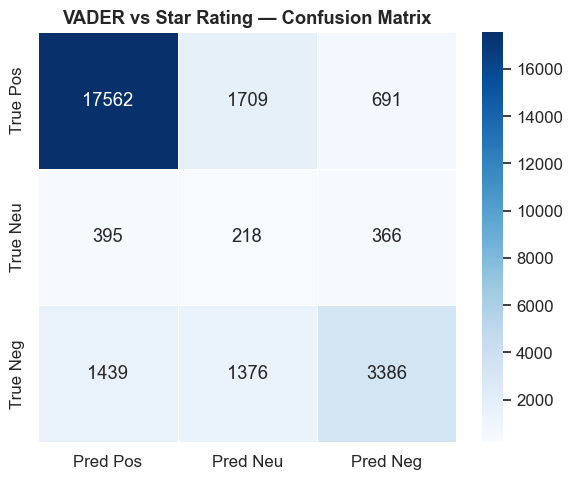

Overall agreement: 78.0%


In [5]:
# Compare VADER label against true sentiment from star rating
from sklearn.metrics import classification_report, confusion_matrix

print('VADER vs Star Rating Agreement:')
print()
print(classification_report(
    df['sentiment'],
    df['vader_label'],
    labels=['Positive','Neutral','Negative'],
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(
    df['sentiment'], df['vader_label'],
    labels=['Positive','Neutral','Negative']
)
cm_df = pd.DataFrame(
    cm,
    index  =['True Pos','True Neu','True Neg'],
    columns=['Pred Pos','Pred Neu','Pred Neg']
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('VADER vs Star Rating — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

overall_acc = (df['sentiment'] == df['vader_label']).mean()
print(f'Overall agreement: {overall_acc:.1%}')


Key insight: VADER struggles most with Neutral (3-star) reviews.
This is expected — neutral text is hardest for rule-based systems.

## 5. VADER Compound Score Distribution by Bank

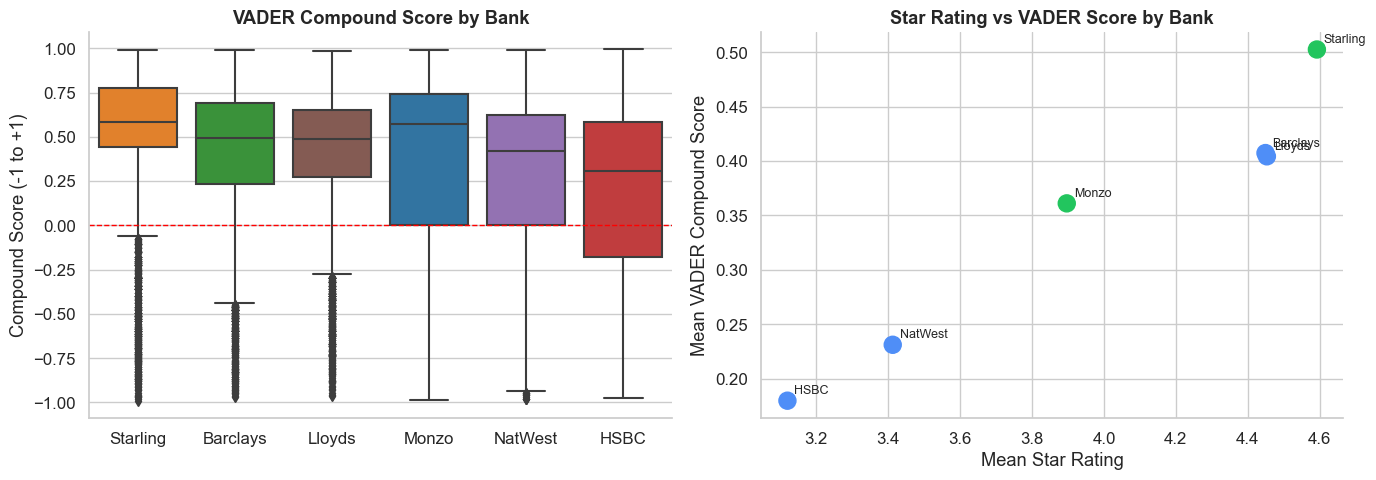

Mean VADER compound score per bank:
bank
Starling    0.502
Barclays    0.407
Lloyds      0.404
Monzo       0.361
NatWest     0.231
HSBC        0.180


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of compound score per bank
order = df.groupby('bank')['vader_compound'].mean().sort_values(ascending=False).index
sns.boxplot(
    data=df, x='bank', y='vader_compound',
    order=order,
    palette=[PALETTE[b] for b in order],
    ax=axes[0]
)
axes[0].set_title('VADER Compound Score by Bank', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Compound Score (-1 to +1)')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

# Mean compound score vs mean star rating
summary = df.groupby('bank').agg(
    mean_rating   = ('rating', 'mean'),
    mean_compound = ('vader_compound', 'mean')
).reset_index()

colors = ['#22c55e' if b in CHALLENGER else '#4f8ef7' for b in summary['bank']]
axes[1].scatter(summary['mean_rating'], summary['mean_compound'],
                c=colors, s=150, zorder=5)
for _, row in summary.iterrows():
    axes[1].annotate(
        row['bank'],
        (row['mean_rating'], row['mean_compound']),
        textcoords='offset points', xytext=(5, 5), fontsize=9
    )
axes[1].set_xlabel('Mean Star Rating')
axes[1].set_ylabel('Mean VADER Compound Score')
axes[1].set_title('Star Rating vs VADER Score by Bank', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print('Mean VADER compound score per bank:')
print(df.groupby('bank')['vader_compound'].mean().sort_values(ascending=False).round(3).to_string())


## 6. Sentiment Drift Over Time

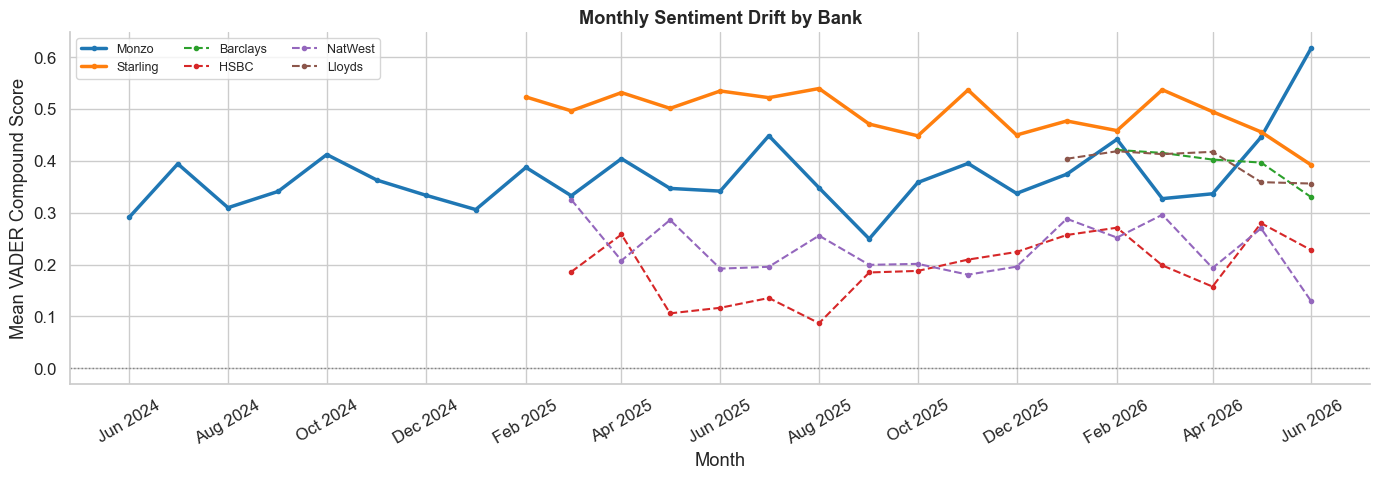

In [9]:
df['year_month_dt'] = pd.to_datetime(df['year_month'])

monthly = df.groupby(['year_month_dt','bank'])['vader_compound'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for bank in BANKS:
    sub = monthly[monthly['bank']==bank].sort_values('year_month_dt')
    lw  = 2.5 if bank in CHALLENGER else 1.5
    ls  = '-'  if bank in CHALLENGER else '--'
    ax.plot(sub['year_month_dt'], sub['vader_compound'],
            label=bank, color=PALETTE[bank], linewidth=lw, linestyle=ls,
            marker='o', markersize=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Month')
ax.set_ylabel('Mean VADER Compound Score')
ax.set_title('Monthly Sentiment Drift by Bank', fontweight='bold')
ax.legend(ncol=3, fontsize=9)

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()


## 7. Aspect-Level Sentiment

Score sentiment on five banking-specific aspects by finding reviews
that mention aspect keywords and scoring those sentences with VADER.

This is a simplified aspect-based sentiment analysis (ABSA) approach.
The full BERT-based ABSA runs in notebook 05 on Colab.


In [14]:
ASPECTS = {
    'Customer Service' : ['customer service','support','help','staff','agent','chat','call'],
    'App & Interface'  : ['interface','design','layout','screen','ui','update','crash','bug','slow','fast','easy'],
    'Fees & Charges'   : ['fee','charge','cost','price','expensive','cheap','interest','rate'],
    'Transfer & Speed' : ['transfer','payment','send','receive','instant','fast','slow','delay','pending','stuck'],
    'Security & Fraud' : ['fraud','scam','hack','secure','security','block','freeze','lock','suspicious'],
}

ASPECT_COLS = {
    'Customer Service' : 'aspect_customer_service',
    'App & Interface'  : 'aspect_app_interface',
    'Fees & Charges'   : 'aspect_fees_charges',
    'Transfer & Speed' : 'aspect_transfer_speed',
    'Security & Fraud' : 'aspect_security_fraud',
}

def score_aspect(text, keywords):
    text_lower = str(text).lower()
    if not any(kw in text_lower for kw in keywords):
        return None
    return sia.polarity_scores(text)['compound']

print('Computing aspect scores...')
for aspect, keywords in ASPECTS.items():
    col = ASPECT_COLS[aspect]
    df[col] = df['text'].apply(lambda x: score_aspect(x, keywords))
    coverage = df[col].notna().mean() * 100
    print(f'  {aspect:<20}: {coverage:.1f}% of reviews mention this aspect')

print()
print('Sample aspect scores for one review:')
sample = df[df['aspect_fees_charges'].notna()].iloc[0]
print(f'  Text     : {sample["text"][:150]}')
print(f'  Rating   : {sample["rating"]}')
print(f'  Compound : {sample["vader_compound"]:.3f}')

Computing aspect scores...
  Customer Service    : 10.2% of reviews mention this aspect
  App & Interface     : 38.6% of reviews mention this aspect
  Fees & Charges      : 4.0% of reviews mention this aspect
  Transfer & Speed    : 10.9% of reviews mention this aspect
  Security & Fraud    : 6.2% of reviews mention this aspect

Sample aspect scores for one review:
  Text     : Brilliant bank! Lots of good things about them such as the possibility of getting a double pay day. They also provide cashback and lots of other perks
  Rating   : 5
  Compound : 0.806


### 7.1 Aspect Sentiment Heatmap

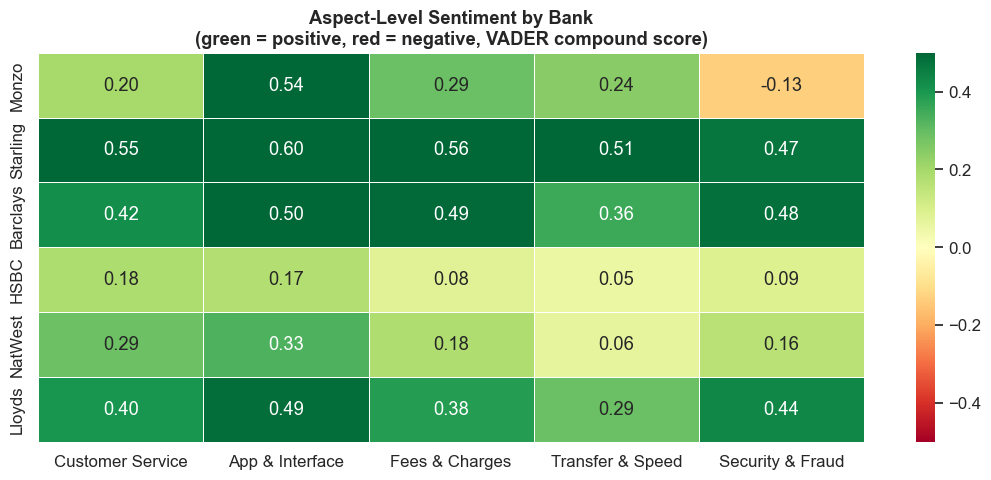

In [16]:
aspect_cols = [
    'aspect_customer_service',
    'aspect_app_interface',
    'aspect_fees_charges',
    'aspect_transfer_speed',
    'aspect_security_fraud',
]
aspect_labels = [
    'Customer Service',
    'App & Interface',
    'Fees & Charges',
    'Transfer & Speed',
    'Security & Fraud',
]

# Mean aspect score per bank
heatmap_data = pd.DataFrame(index=BANKS, columns=aspect_labels)
for bank in BANKS:
    sub = df[df['bank']==bank]
    for col, label in zip(aspect_cols, aspect_labels):
        heatmap_data.loc[bank, label] = sub[col].mean()

heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax
)
ax.set_title('Aspect-Level Sentiment by Bank\n'
             '(green = positive, red = negative, VADER compound score)',
             fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Key findings:

- Which aspect gets the most negative scores across all banks?
- Which bank scores best/worst on Security & Fraud?
- Do challenger banks outperform traditional banks on App & Interface?

## 8. VADER Summary per Bank

In [17]:
summary = df.groupby('bank').agg(
    mean_compound  = ('vader_compound', 'mean'),
    pct_positive   = ('vader_label', lambda x: (x=='Positive').mean()*100),
    pct_negative   = ('vader_label', lambda x: (x=='Negative').mean()*100),
    agreement_rate = ('sentiment', lambda x: (x == df.loc[x.index,'vader_label']).mean()*100),
).round(2)
summary['type'] = ['Challenger' if b in CHALLENGER else 'Traditional'
                   for b in summary.index]
summary = summary.sort_values('mean_compound', ascending=False)

print('VADER Summary per Bank:')
print(summary.to_string())
print()
print('Overall VADER-Star agreement: {:.1f}%'.format(
    (df['sentiment']==df['vader_label']).mean()*100
))


VADER Summary per Bank:
          mean_compound  pct_positive  pct_negative  agreement_rate         type
bank                                                                            
Starling           0.50         84.79          7.78           86.96   Challenger
Barclays           0.41         77.84         10.44           80.85  Traditional
Lloyds             0.40         78.71          9.88           82.60  Traditional
Monzo              0.36         71.03         18.25           79.80   Challenger
NatWest            0.23         59.93         24.24           70.77  Traditional
HSBC               0.18         56.64         27.44           67.00  Traditional

Overall VADER-Star agreement: 78.0%


## 9. Save

In [18]:
df.to_csv(PROCESSED_DIR / 'reviews_vader.csv', index=False)
print('Saved: reviews_vader.csv')
print(f'  Shape  : {df.shape}')
print()
print('New columns added:')
new_cols = [c for c in df.columns if c.startswith('vader') or c.startswith('aspect')]
for col in new_cols:
    print(f'  {col}')


Saved: reviews_vader.csv
  Shape  : (27142, 28)

New columns added:
  vader_pos
  vader_neu
  vader_neg
  vader_compound
  vader_label
  aspect_customer_service
  aspect_app_interface
  aspect_fees_charges
  aspect_transfer_speed
  aspect_security_fraud
